In [11]:
# === Decision boundary plotting from a run folder (α vs β) ===
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [16]:
# --- Decision boundary plotting cell (now uses Dataset.split_census_income and overlays best_synthetic.csv) ---

import os, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

# Your project imports
from agents.ffnn_agent2 import FFNNAgent      # agent wrapper (model outputs [N,2] logits)
from dataset import Dataset                   # <-- NEW: use this to reconstruct splits when needed

# ----------------------------
# Helpers for files & loading
# ----------------------------
def _is_seed_dir(path: str) -> bool:
    return (
        os.path.isdir(path)
        and os.path.isfile(os.path.join(path, "metrics.csv"))
        and os.path.isfile(os.path.join(path, "meta.json"))
    )

def _find_seed_dir(run_dir: str) -> str:
    run_dir = os.path.abspath(run_dir.rstrip("/"))
    if _is_seed_dir(run_dir):
        return run_dir
    seed_dirs = sorted([os.path.join(run_dir, d) for d in os.listdir(run_dir) if d.startswith("seed_")])
    seed_dirs = [sd for sd in seed_dirs if _is_seed_dir(sd)]
    if len(seed_dirs) == 1:
        return seed_dirs[0]
    if len(seed_dirs) > 1:
        print(f"[info] Experiment root with multiple seeds; using first: {os.path.basename(seed_dirs[0])}")
        return seed_dirs[0]
    raise FileNotFoundError("Could not locate a valid seed directory under: " + run_dir)

def _read_json(path: Path) -> dict:
    try:
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
    except Exception:
        pass
    return {}

def _maybe_to_numpy(x):
    if torch is not None and isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _try_load_array(run_dir: str, base_names):
    """
    Try several common filenames (npy/npz/pt/csv) for arrays.
    Returns ndarray or None.
    """
    candidates = []
    for name in base_names:
        candidates += glob.glob(os.path.join(run_dir, name))
    for p in candidates:
        ext = os.path.splitext(p)[1].lower()
        try:
            if ext == ".npy":
                return np.load(p)
            elif ext == ".npz":
                with np.load(p) as npz:
                    return npz[list(npz.files)[0]]
            elif ext == ".csv":
                return pd.read_csv(p).values
            elif ext in (".pt", ".pth"):
                arr = torch.load(p, map_location="cpu")
                if isinstance(arr, dict):
                    for k in ("x", "X", "data", "array", "x_test", "y_test"):
                        if k in arr:
                            arr = arr[k]
                            break
                return _maybe_to_numpy(arr)
        except Exception as e:
            print(f"[warn] failed to load {p}: {e}")
    return None

def _load_data_arrays(seed_dir: str):
    """
    Tries to load x_test, y_test, x_train, y_train from common filenames in the seed dir.
    Returns (x_test, y_test, x_train, y_train) as ndarrays or None.
    Expected shape for x_* is [N, 2] (already PCA'd).
    """
    x_test = _try_load_array(seed_dir, ["x_test.npy", "X_test.npy", "x_test.pt", "test_x.npy", "test.npz", "test.pt"])
    y_test = _try_load_array(seed_dir, ["y_test.npy", "Y_test.npy", "y_test.pt", "test_y.npy"])
    x_train = _try_load_array(seed_dir, ["x_train.npy", "X_train.npy", "x_train.pt", "train_x.npy", "train.npz", "train.pt"])
    y_train = _try_load_array(seed_dir, ["y_train.npy", "Y_train.npy", "y_train.pt", "train_y.npy"])
    return x_test, y_test, x_train, y_train

# ---------------------------------------
# State dict remapping & agent rehydration
# ---------------------------------------
def _detect_model_prefix(model: nn.Module) -> str:
    for k in model.state_dict().keys():
        return k.split(".", 1)[0]
    return "net"

def _remap_prefix(state_dict: dict, src_prefix: str, dst_prefix: str) -> dict:
    if src_prefix == dst_prefix:
        return state_dict
    remapped = {}
    src_head = src_prefix + "."
    dst_head = dst_prefix + "."
    for k, v in state_dict.items():
        if k.startswith(src_head):
            remapped[dst_head + k[len(src_head):]] = v
        else:
            remapped[k] = v
    return remapped

def _normalize_state_dict_to_model(state_path: Path, model: nn.Module) -> dict:
    sd = torch.load(state_path, map_location="cpu")
    if not isinstance(sd, dict):
        raise ValueError(f"Checkpoint at {state_path} is not a plain state_dict.")
    model_prefix = _detect_model_prefix(model)
    for src in ["network", "net"]:
        sd = _remap_prefix(sd, src, model_prefix)
    return sd

def _build_ffnn_config_from_meta(seed_dir: Path, default_device="cpu"):
    meta_path = seed_dir / "ffnn_meta.json"
    meta = _read_json(meta_path)
    cfg = {
        "input_size": int(meta.get("n_pca_components", 2)),
        "hidden_sizes": meta.get("hidden_sizes", [32, 16]),
        "output_size": meta.get("output_size", 2),
        "learning_rate": meta.get("learning_rate", 0.001),
        "batch_size": meta.get("batch_size", 32),
        "epochs": meta.get("epochs", 10),
        "type": meta.get("type", "classification"),
        "classes": meta.get("classes", [0, 1]),
        "device": default_device,
        "seed": meta.get("seed", 42),
    }
    return cfg, int(meta.get("n_pca_components", 2))

def _load_agent_from_ckpt(seed_dir: Path, ckpt_name: str, label: str):
    cfg, _ = _build_ffnn_config_from_meta(seed_dir, default_device="cpu")
    agent = FFNNAgent(**cfg)
    model = agent.model
    ckpt_path = seed_dir / ckpt_name
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")
    sd = _normalize_state_dict_to_model(ckpt_path, model)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing or unexpected:
        print(f"[warn] {label} load_state_dict mismatches — missing:{list(missing)} unexpected:{list(unexpected)}")
    else:
        print(f"[ok] {label} weights loaded from {ckpt_path.name}")
    return agent

# ---------------------------------------
# Meta + split reconstruction using Dataset
# ---------------------------------------
def _load_meta(seed_dir: str | Path) -> dict:
    seed_dir = Path(seed_dir)
    meta_path = seed_dir / "meta.json"
    if meta_path.exists():
        try:
            with open(meta_path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception as e:
            print(f"[warn] failed reading {meta_path}: {e}")
    return {}

def _reconstruct_splits_from_meta(seed_dir: str | Path, meta: dict):
    """
    Recreate PCA(2D) θ_train/val/test splits using Dataset.split_census_income
    with the run's seed/bias/size config.
    Returns numpy arrays: (X_train, X_val, X_test, y_train, y_val, y_test).
    """
    # Fix: ensure random_state is int, not str, for sklearn compatibility
    seed      = int(meta.get("seed", 42))
    bias_pct  = float(meta.get("BIAS_PCT", 0.35))
    real_size = int(meta.get("REAL_DATA_SIZE", 3000))

    # Pass seed as int, not str, to Dataset so that train_test_split gets an int random_state
    ds = Dataset(seed=seed, device="cpu")
    Xtr, Xval, Xte, Ytr, Yval, Yte = ds.split_census_income(
        train_size=real_size, bias_pct=bias_pct, pca_components=2
    )

    to_np = lambda t: t.detach().cpu().numpy() if hasattr(t, "detach") else np.asarray(t)
    return tuple(to_np(x) for x in (Xtr, Xval, Xte, Ytr, Yval, Yte))

# ---------------------------------------
# Plotting
# ---------------------------------------
from matplotlib.lines import Line2D

def plot_decision_boundaries_for_run(
    run_dir: str,
    alpha_agent,
    beta_agent,
    f1_thresh: float = 0.5,
    grid_pad: float = 0.08,
    grid_res: int = 300,
    save_png: bool = True,
    *,
    show_both_correct: bool = False,
    show_both_wrong: bool = False,
    overlay_size: int = 50,
    overlay_alpha: float = 1.0,
    show_test_majority: bool = True,
    show_test_minority: bool = True,
    show_synth_minority: bool = True
):
    """
    Plot α vs β decision boundaries and Δp heatmap on 2D PCA space for a single run folder.
    Also overlays synthetic points from best_synthetic.csv (pca_0,pca_1,target) if present.

    Parameters
    ----------
    show_test_majority : bool
        If True, show test majority (y=0) points.
    show_test_minority : bool
        If True, show test minority (y=1) points.
    show_synth_minority : bool
        If True, show synthetic minority (y=1) points from best_synthetic.csv.
    """
    seed_dir = _find_seed_dir(run_dir)
    meta = _load_meta(seed_dir)

    # --- Load (or reconstruct) datasets ---
    x_test, y_test, x_train, y_train = _load_data_arrays(seed_dir)
    if x_test is None or y_test is None:
        print("[info] x_test/y_test not found; reconstructing via Dataset.split_census_income(...)")
        Xtr, Xval, Xte, Ytr, Yval, Yte = _reconstruct_splits_from_meta(seed_dir, meta)
        x_test, y_test, x_train, y_train = Xte, Yte, Xtr, Ytr

    x_test = np.asarray(x_test); y_test = np.asarray(y_test).astype(int).ravel()
    assert x_test.shape[1] == 2, f"x_test must be [N,2]; got {x_test.shape}"

    # --- Grid over extents (include only real data for extents; synthetic just overlays) ---
    all_X = x_test if x_train is None else np.vstack([x_train, x_test])
    xmin, ymin = all_X.min(axis=0); xmax, ymax = all_X.max(axis=0)
    x_range, y_range = xmax - xmin, ymax - ymin
    xmin -= grid_pad * x_range; xmax += grid_pad * x_range
    ymin -= grid_pad * y_range; ymax += grid_pad * y_range

    xx = np.linspace(xmin, xmax, grid_res)
    yy = np.linspace(ymin, ymax, grid_res)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.c_[XX.ravel(), YY.ravel()]

    # --- Predict helpers ---
    def _p1(agent, Xnp):
        with torch.no_grad():
            X = torch.from_numpy(Xnp.astype(np.float32))
            logits = agent.model(X)
            return torch.softmax(logits, -1)[..., 1].cpu().numpy()

    p_alpha_grid = _p1(alpha_agent, grid).reshape(XX.shape)
    p_beta_grid  = _p1(beta_agent,  grid).reshape(XX.shape)
    delta_grid   = p_beta_grid - p_alpha_grid

    p_alpha_test = _p1(alpha_agent, x_test).ravel()
    p_beta_test  = _p1(beta_agent,  x_test).ravel()
    yhat_a = (p_alpha_test >= f1_thresh).astype(int)
    yhat_b = (p_beta_test  >= f1_thresh).astype(int)

    # Four outcome masks
    wins_mask     = (yhat_a != y_test) & (yhat_b == y_test)   # β fixes α
    losses_mask   = (yhat_a == y_test) & (yhat_b != y_test)   # β breaks α
    both_correct  = (yhat_a == y_test) & (yhat_b == y_test)
    both_wrong    = (yhat_a != y_test) & (yhat_b != y_test)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8.5, 7))

    vmax = float(np.nanmax(np.abs(delta_grid))) if np.isfinite(delta_grid).any() else 1.0
    im = ax.imshow(delta_grid, origin="lower",
                   extent=[xmin, xmax, ymin, ymax],
                   aspect="auto", alpha=0.65, vmin=-vmax, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Δp = pβ − pα")

    # Decision contours (proxies added to legend below)
    try:
        ax.contour(XX, YY, p_alpha_grid, levels=[f1_thresh],
                   linewidths=2, linestyles="--", colors=["black"])
    except Exception:
        pass
    try:
        ax.contour(XX, YY, p_beta_grid, levels=[f1_thresh],
                   linewidths=2, linestyles="-", colors=["black"])
    except Exception:
        pass

    # Test scatter (with toggles)
    if show_test_majority:
        ax.scatter(x_test[y_test==0, 0], x_test[y_test==0, 1], s=12, alpha=0.75, label="Test majority (y=0)")
    if show_test_minority:
        ax.scatter(x_test[y_test==1, 0], x_test[y_test==1, 1], s=12, alpha=0.75, label="Test minority (y=1)")

    # --- Overlay synthetic points from best_synthetic.csv (pca_0,pca_1,target) ---
    try:
        synth_csv = Path(seed_dir) / "best_synthetic.csv"
        if synth_csv.exists():
            df_s = pd.read_csv(synth_csv)
            if {"pca_0", "pca_1", "target"}.issubset(df_s.columns):
                Xs = df_s[["pca_0", "pca_1"]].to_numpy()
                ys = df_s["target"].to_numpy().astype(int).ravel()
                if (ys == 0).any():
                    ax.scatter(
                        Xs[ys == 0, 0], Xs[ys == 0, 1],
                        s=24, marker="^", facecolors="none", edgecolors="#6a5acd", linewidths=1.2,
                        alpha=0.95, label="Synthetic majority (y=0)"
                    )
                if show_synth_minority and (ys == 1).any():
                    ax.scatter(
                        Xs[ys == 1, 0], Xs[ys == 1, 1],
                        s=24, marker="^", alpha=0.95,
                        label="Synthetic minority (y=1)"
                    )
            else:
                print("[warn] best_synthetic.csv missing columns pca_0,pca_1,target; skipping overlay.")
        else:
            print("[info] No best_synthetic.csv found in seed dir; skipping synthetic overlay.")
    except Exception as e:
        print(f"[warn] Failed to overlay synthetic points: {e}")

    # Always-on overlays: β fixes α (green ring) / β breaks α (red ring)
    # Only show these overlays if at least one of show_test_majority or show_test_minority is True
    if show_test_majority or show_test_minority:
        if wins_mask.any():
            ax.scatter(x_test[wins_mask, 0], x_test[wins_mask, 1],
                       s=overlay_size, facecolors='none', edgecolors='green',
                       linewidths=1.6, alpha=overlay_alpha, label="β fixes α")
        if losses_mask.any():
            ax.scatter(x_test[losses_mask, 0], x_test[losses_mask, 1],
                       s=overlay_size, facecolors='none', edgecolors='red',
                       linewidths=1.6, alpha=overlay_alpha, label="β breaks α")

    # Optional overlays
    if show_both_correct and both_correct.any():
        ax.scatter(x_test[both_correct, 0], x_test[both_correct, 1],
                   s=overlay_size, facecolors='none', edgecolors='#00bcd4',
                   marker='D', linewidths=1.4, alpha=overlay_alpha, label="both correct")
    if show_both_wrong and both_wrong.any():
        ax.scatter(x_test[both_wrong, 0], x_test[both_wrong, 1],
                   s=overlay_size, c='black', marker='x',
                   linewidths=1.2, alpha=overlay_alpha, label="both wrong")

    # Proxies for contours so legend text is clear
    proxy_alpha = Line2D([0], [0], color="black", lw=2, ls="--", label="α boundary")
    proxy_beta  = Line2D([0], [0], color="black", lw=2, ls="-",  label="β boundary")

    handles, labels = ax.get_legend_handles_labels()
    handles = [proxy_alpha, proxy_beta] + handles
    labels  = [h.get_label() for h in [proxy_alpha, proxy_beta]] + labels

    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    exp_name = os.path.basename(os.path.dirname(seed_dir))
    seed_name = os.path.basename(seed_dir)
    ax.set_title(f"Decision Boundaries in PCA(2D)\nRun: {exp_name} / {seed_name}")
    ax.legend(handles, labels, loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()

    if save_png:
        out_png = os.path.join(seed_dir, "decision_boundary.png")
        plt.savefig(out_png, dpi=180)
        print(f"[info] Saved decision boundary plot → {out_png}")

    plt.show()


FFNN Using device: cpu
[ok] Alpha weights loaded from alpha_state_dict.pt
FFNN Using device: cpu
[ok] Beta weights loaded from best_beta_state_dict.pt
[info] x_test/y_test not found; reconstructing via Dataset.split_census_income(...)
[TRAIN] size=3000, minority=722 (24.07%)
[VAL] size=6512, minority=1568 (24.08%)
[TEST] size=6513, minority=1569 (24.09%)
[info] Saved decision boundary plot → /home/epigou/cs_9170_project/training_runs/EP1000_TRJ2000_REAL3000_BIAS0.35_LS0.8-0.8_MODEgauss_nopen_TAU0.1_G202509172018_64cd83df/seed_999/decision_boundary.png


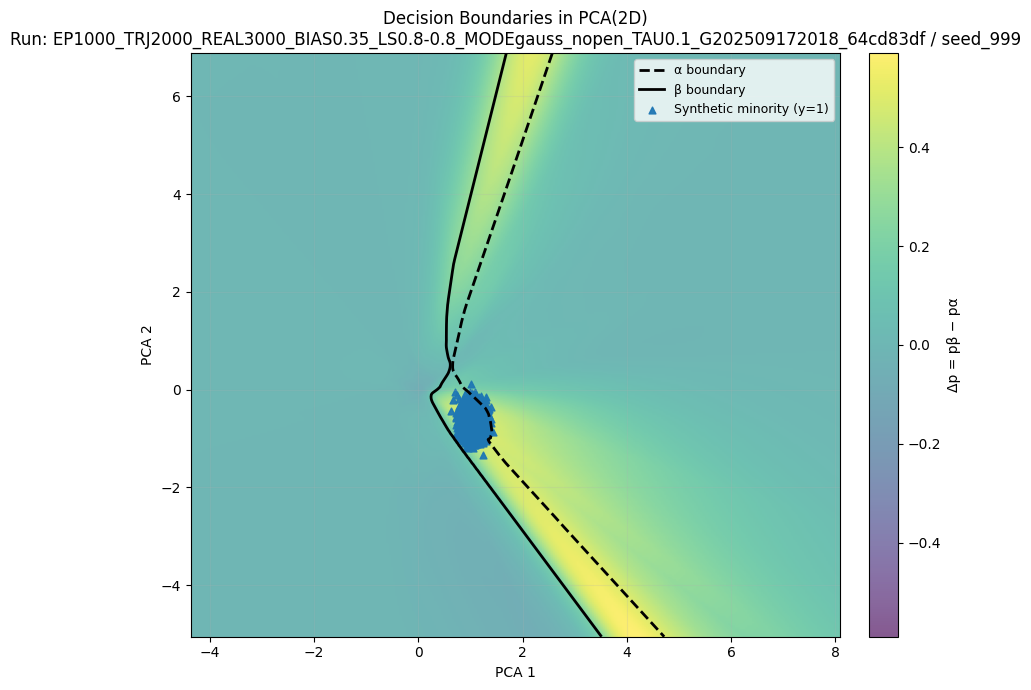

In [17]:
# ---- Usage ----
RUN_DIR = "training_runs/EP1000_TRJ2000_REAL3000_BIAS0.35_LS0.8-0.8_MODEgauss_nopen_TAU0.1_G202509172018_64cd83df/seed_999"
seed_dir = Path(_find_seed_dir(RUN_DIR))
# Build α/β agents from saved state dicts, remapping 'network.' -> model prefix if needed.
alpha_agent = _load_agent_from_ckpt(seed_dir, "alpha_state_dict.pt", label="Alpha")
beta_agent  = _load_agent_from_ckpt(seed_dir, "best_beta_state_dict.pt", label="Beta")

# Plot
plot_decision_boundaries_for_run(RUN_DIR, alpha_agent, beta_agent, f1_thresh=0.5, show_both_correct=False, show_both_wrong=False,     
    show_test_majority= False,
    show_test_minority= False,
    show_synth_minority= True)

In [14]:
# --- Cell: Plot only synthetic minority points and α/β boundaries ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import torch

def plot_synthetic_minority_with_boundaries(run_dir: str,
                                            alpha_agent,
                                            beta_agent,
                                            f1_thresh: float = 0.5,
                                            grid_pad: float = 0.08,
                                            grid_res: int = 300,
                                            save_png: bool = True):
    seed_dir = _find_seed_dir(run_dir)

    # --- Load synthetic data ---
    synth_csv = Path(seed_dir) / "best_synthetic.csv"
    if not synth_csv.exists():
        print(f"[info] No best_synthetic.csv found in {seed_dir}")
        return

    df_s = pd.read_csv(synth_csv)
    if not {"pca_0", "pca_1", "target"}.issubset(df_s.columns):
        print("[warn] best_synthetic.csv missing columns pca_0,pca_1,target")
        return

    # Only minority points
    df_minority = df_s[df_s["target"] == 1]
    if df_minority.empty:
        print("[info] No minority synthetic samples found.")
        return

    Xs = df_minority[["pca_0", "pca_1"]].to_numpy()

    # --- Define grid extent from synthetic points ---
    xmin, ymin = Xs.min(axis=0); xmax, ymax = Xs.max(axis=0)
    x_range, y_range = xmax - xmin, ymax - ymin
    xmin -= grid_pad * x_range; xmax += grid_pad * x_range
    ymin -= grid_pad * y_range; ymax += grid_pad * y_range

    xx = np.linspace(xmin, xmax, grid_res)
    yy = np.linspace(ymin, ymax, grid_res)
    XX, YY = np.meshgrid(xx, yy)
    grid = np.c_[XX.ravel(), YY.ravel()]

    # --- Prediction helper ---
    def _p1(agent, Xnp):
        with torch.no_grad():
            X = torch.from_numpy(Xnp.astype(np.float32))
            logits = agent.model(X)
            return torch.softmax(logits, -1)[..., 1].cpu().numpy()

    p_alpha_grid = _p1(alpha_agent, grid).reshape(XX.shape)
    p_beta_grid  = _p1(beta_agent,  grid).reshape(XX.shape)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # α boundary (dashed), β boundary (solid)
    ax.contour(XX, YY, p_alpha_grid, levels=[f1_thresh],
               linewidths=2, linestyles="--", colors=["black"], label="α boundary")
    ax.contour(XX, YY, p_beta_grid, levels=[f1_thresh],
               linewidths=2, linestyles="-", colors=["black"], label="β boundary")

    # Synthetic minority scatter
    ax.scatter(Xs[:, 0], Xs[:, 1],
               s=30, marker="^", alpha=0.9, color="tab:purple",
               label="Synthetic minority (y=1)")

    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.set_title("Synthetic Minority Data with Decision Boundaries")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if save_png:
        out_png = os.path.join(seed_dir, "synthetic_minority_boundaries.png")
        plt.savefig(out_png, dpi=180)
        print(f"[info] Saved → {out_png}")

    plt.show()


/tmp/ipykernel_13815/2335390802.py:62: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipykernel_13815/2335390802.py:64: UserWarning:

The following kwargs were not used by contour: 'label'



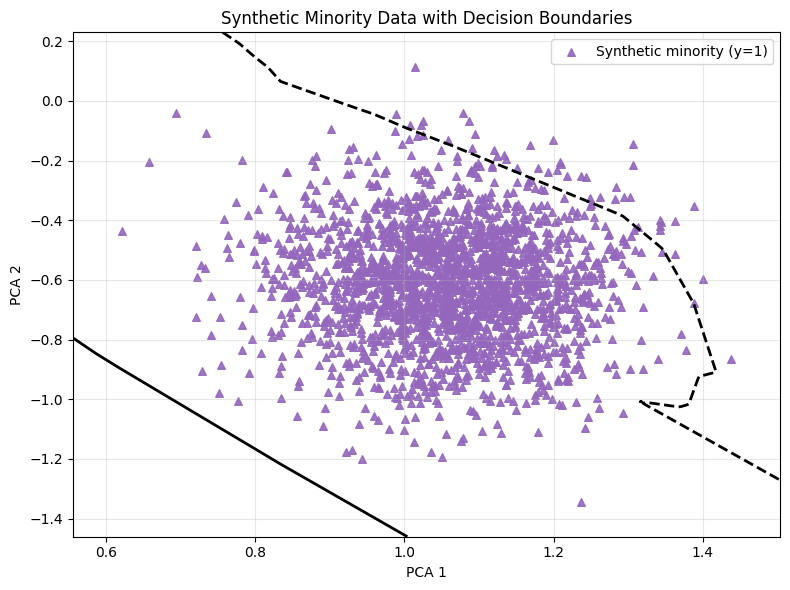

In [15]:
plot_synthetic_minority_with_boundaries(
    "training_runs/EP1000_TRJ2000_REAL3000_BIAS0.35_LS0.8-0.8_MODEgauss_nopen_TAU0.1_G202509172018_64cd83df/seed_999",
    alpha_agent,
    beta_agent,
    f1_thresh=0.5,
    grid_pad=0.08,
    grid_res=300,
    save_png=False
)